# developing comp_scenario_pnt

## Importing + Setting Up Data for Function

In [81]:
## So that if you change sth in a src script you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [82]:
## Imports
## Allowing for Imports from src folder
import sys
sys.path.append("..") # Adds the project root to the path

In [83]:
## Getting hazard Dict
from src.data_hazard import get_haz_dict

## TODO: Enable Floods!
haz_dict = get_haz_dict()

haz_dict

{'TC': {'hazard': <climada.hazard.base.Hazard at 0x160f3a330>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x34ff5c2c0>},
 'TP': {'hazard': <climada.hazard.base.Hazard at 0x33728c1a0>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x3372abbc0>},
 'HL': {'hazard': <climada.hazard.base.Hazard at 0x160f38200>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x160f5afc0>}}

In [84]:
from src.data_exposure import get_exposure

hazard_types = list(haz_dict.keys())

exposure_poly = get_exposure(hazard_types=hazard_types)

exposure_poly_gdf = exposure_poly.gdf

exposure_poly_gdf.head()

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,insurance,impf_TC,impf_TP,impf_HL,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,0.30,1,1,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,0.32,1,1,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,0.30,1,1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,0.18,1,1,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,0.18,1,1,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."


In [91]:
import climada.util.lines_polys_handler as u_lp

# TODO: Adjust Resolution
exposure_pnt = u_lp.exp_geom_to_pnt(
    exposure_poly,
    res=1000,
    to_meters=True,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=None,
)

exposure_pnt_gdf = exposure_pnt.gdf

In [92]:
from src.helpers import comp_impact

exposure_pnt_gdf["eai"] = comp_impact(
    haz_dict=haz_dict,
    exposure_pnt_gdf=exposure_pnt_gdf
)

Computing TC
Computing TP
Computing HL
2026-04-24 16:46:36,086 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000237 degree for 548477 coordinates.


## One Cycle

In [97]:
import numpy as np

## Function Arguments:
exposure_pnt_gdf = exposure_pnt_gdf
insurance_method = "coverage" # Standard
insurance_scaling_factors = np.linspace(0, 1, 11) # Standard

In [98]:
scaling_factor = insurance_scaling_factors[10]

In [99]:
from copy import deepcopy
scenario_pnt = deepcopy(exposure_pnt_gdf)

In [100]:
scenario_pnt["eai"].max()

1.0

In [101]:
from src.helpers import comp_insurance

scenario_pnt["insurance"] = comp_insurance(
    method=insurance_method,
    scaling_factor=scaling_factor,
    insurance_current=scenario_pnt["insurance"],
    eai=scenario_pnt["eai"]
)

In [102]:
from src.helpers import comp_who_pays

result = comp_who_pays(
    relative_damage=scenario_pnt["eai"],
    insured=scenario_pnt["insurance"]
)

scenario_pnt[["F", "I", "G"]] = result[["F", "I", "G"]].to_numpy()

In [103]:
## Computing Relative Payments
result = (scenario_pnt[['F', 'I', 'G']]
          .mul(scenario_pnt['eai'], axis=0)
          .mul(scenario_pnt["value"], axis=0)
          )

scenario_pnt = scenario_pnt.join(result.add_suffix('_relative'))

In [104]:
from src.helpers import agg_to_departement

scenario_poly = agg_to_departement(
    pnt_gdf=scenario_pnt,
    value_cols=["value", "insurance", "eai", "F", "I", "G", "F_relative", "I_relative", "G_relative"],
    agg_func="mean"
)

In [105]:
## Damage Map

result = scenario_poly[['F_relative', 'I_relative', 'G_relative']].mul(
    scenario_poly['area'], axis=0
)

result.columns = ['F_area', 'I_area', 'G_area']

scenario_poly = scenario_poly.join(result)

In [106]:
scenario_poly["I_relative"].max()

0.00016312036613865344

In [107]:
insured_area = (scenario_poly["insurance"] * scenario_poly["area"]).sum()

In [108]:
who_pays_what = {
    "F": scenario_poly["F_area"].sum(),
    "I": scenario_poly["I_area"].sum(),
    "G": scenario_poly["G_area"].sum()
}

## Export Format

In [109]:
results = {
    0.1: {
        "scenario_pnt": scenario_pnt,
        "scenario_poly": scenario_poly,
        "who_pays_what": who_pays_what,
        "insured_area": insured_area
    }
}

# Building Function

In [113]:
import geopandas as gpd
import numpy as np

from src.helpers import comp_insurance
from src.helpers import comp_who_pays
from src.helpers import agg_to_departement

def comp_scenarios(
    exposure_pnt_gdf: gpd.GeoDataFrame = exposure_pnt_gdf,
    insurance_method: str = "coverage",
    insurance_scaling_factors: np.array = np.linspace(0, 1, 11) # Standard
) -> dict:
    
    final_results = {}
    
    for scaling_factor in insurance_scaling_factors:
        
        scenario_pnt = deepcopy(exposure_pnt_gdf)
        
        scenario_pnt["insurance"] = comp_insurance(
            method=insurance_method,
            scaling_factor=scaling_factor,
            insurance_current=scenario_pnt["insurance"],
            eai=scenario_pnt["eai"]
        )
        
        result = comp_who_pays(
            relative_damage=scenario_pnt["eai"],
            insured=scenario_pnt["insurance"]
        )

        scenario_pnt[["F", "I", "G"]] = result[["F", "I", "G"]].to_numpy()
        
        result = (scenario_pnt[['F', 'I', 'G']]
                .mul(scenario_pnt['eai'], axis=0)
                .mul(scenario_pnt["value"], axis=0)
                )

        scenario_pnt = scenario_pnt.join(result.add_suffix('_relative'))
        
        scenario_poly = agg_to_departement(
            pnt_gdf=scenario_pnt,
            value_cols=["value", "insurance", "eai", "F", "I", "G", "F_relative", "I_relative", "G_relative"],
            agg_func="mean"
        )
        
        result = scenario_poly[['F_relative', 'I_relative', 'G_relative']].mul(
            scenario_poly['area'], axis=0
        )

        result.columns = ['F_area', 'I_area', 'G_area']

        scenario_poly = scenario_poly.join(result)
        
        insured_area = (scenario_poly["insurance"] * scenario_poly["area"]).sum()
        
        who_pays_what = {
            "F": scenario_poly["F_area"].sum(),
            "I": scenario_poly["I_area"].sum(),
            "G": scenario_poly["G_area"].sum()
        }
        
        final_results[scaling_factor] = {
                "scenario_pnt": deepcopy(scenario_pnt),
                "scenario_poly": deepcopy(scenario_poly),
                "who_pays_what": deepcopy(who_pays_what),
                "insured_area": deepcopy(insured_area)
        }
        
    return final_results

## Testing Function

In [123]:

final_results = comp_scenarios(exposure_pnt_gdf=exposure_pnt_gdf)

In [124]:
insurance_scaling_factors = []
insured_area = []
f = []
i = []
g = []

for label, scenario_dict in final_results.items():
    
    insurance_scaling_factors.append(label)
    insured_area.append(scenario_dict["insured_area"])
    
    who_pays_what = scenario_dict["who_pays_what"]
    
    f.append(who_pays_what["F"])
    i.append(who_pays_what["I"])
    g.append(who_pays_what["G"])

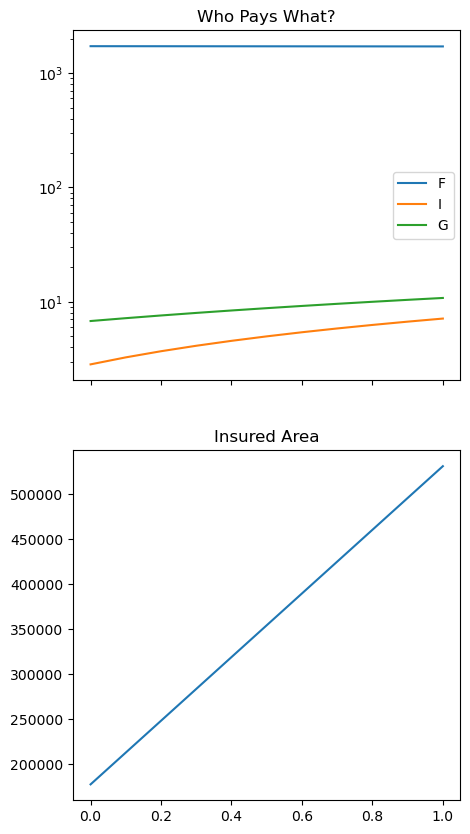

In [126]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1,
                      figsize = (5, 10),
                      sharex=True)

ax = axs[0]
ax.set_title("Who Pays What?")
ax.set_yscale('log')
ax.plot(insurance_scaling_factors,
        f, label="F")
ax.plot(insurance_scaling_factors,
        i, label="I")
ax.plot(insurance_scaling_factors,
        g, label="G")
ax.legend()


ax = axs[1]
ax.set_title("Insured Area")
ax.plot(insurance_scaling_factors,
        insured_area, label="insured area")

plt.show()